In [1]:
%matplotlib inline

85 98 110
33454532.268715672 12197074.837198706
23948457.169218104 9045243.35217415
42006143.55965719 35359787.977776445
9102950.03065642 53566897.443221994


Text(0.5, 1.0, 'Normalized Contributions to the low energy and high energy bins')

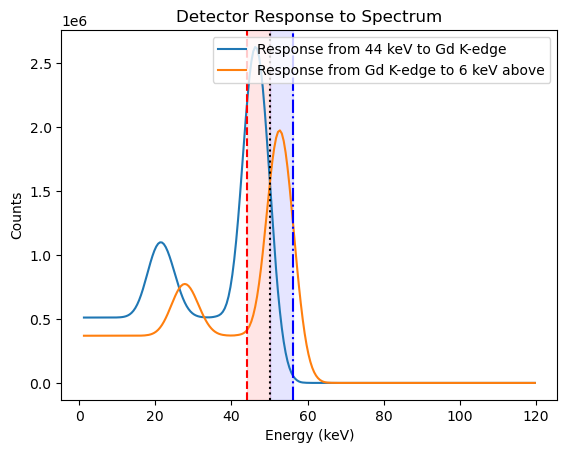

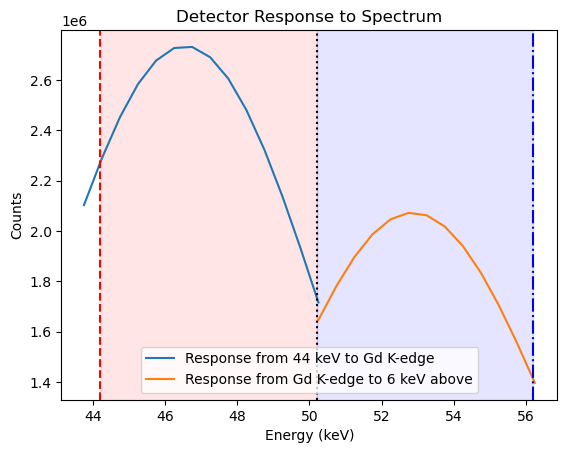

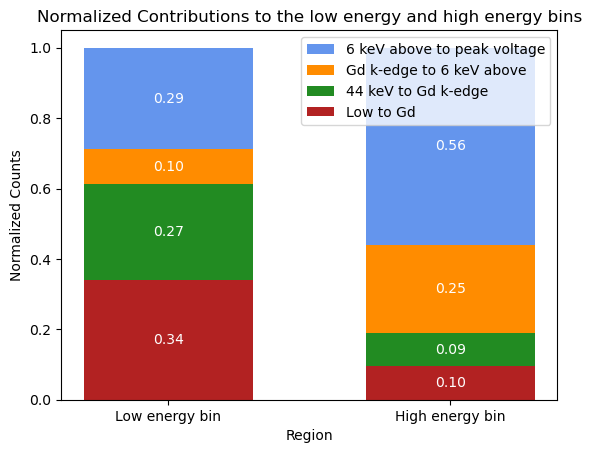

In [ ]:

from cProfile import label

from networkx import second_order_centrality

ind_44 = np.argmin(np.abs(xx-(k_gd-6)))
ind_k_gd = np.argmin(np.abs(xx-k_gd))
ind_k_gd_high = np.argmin(np.abs(xx-(k_gd+6)))

# ind_44 = np.argmin(np.abs(xx-44))
# ind_k_gd = np.argmin(np.abs(xx-k_gd))
# ind_k_gd_high = np.argmin(np.abs(xx-(k_gd+6)))

plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx[ind_44:ind_k_gd+1],np.array(energy_responses[:]).T[ind_44:ind_k_gd+1])#,label='Response from 44 keV to Gd K-edge')
plt.plot(xx[ind_k_gd:ind_k_gd_high+1],np.sum(np.array(energy_responses[:]).T,axis=1)[ind_k_gd:ind_k_gd_high+1],label='Response from Gd K-edge to 6 keV above')
# plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_gd, color='k', linestyle=':')#,label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_gd - 6, color='r', linestyle='--')#, label=f'low-energy threshold {k_gd - 6} keV')
plt.axvline(k_gd + 6, color='b', linestyle='-.')#, label=f'high-energy threshold {k_gd + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_gd-6, k_gd, color='r', alpha=0.1)#, label='Gd low-energy image')
plt.axvspan(k_gd, k_gd + 6, color='b', alpha=0.1)#, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()


contribution_44_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_gd+1]).T,axis=1)[ind_44:ind_k_gd+1])
contribution_gd_to_6_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_k_gd:ind_k_gd_high+1]).T,axis=1)[ind_44:ind_k_gd+1])

print(contribution_44_to_gd_44_to_Gd, contribution_gd_to_6_44_to_Gd)

contribution_gd_to_6_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_k_gd:ind_k_gd_high+1]).T,axis=1)[ind_k_gd:ind_k_gd_high+1])
contribution_44_to_gd_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_gd+1]).T,axis=1)[ind_k_gd:ind_k_gd_high+1])

print(contribution_gd_to_6_gd_to_6, contribution_44_to_gd_gd_to_6)

contribution_low_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[:ind_k_gd+1]).T,axis=1)[ind_44:ind_k_gd+1])

weighted_attenuation_low = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_44:ind_k_gd+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_low.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_44:ind_k_gd+1])/total_signal)

weighted_attenuation_high = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_k_gd:ind_k_gd_high+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_high.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_k_gd:ind_k_gd_high+1])/total_signal)

plt.figure()
plt.title('Weighted Attenuation')
plt.plot(xx, weighted_attenuation_low)
plt.plot(xx, weighted_attenuation_high)
plt.axvline(k_gd, color='k', linestyle=':',label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_gd - 6, color='r', linestyle='--', label=f'low-energy threshold {k_gd - 6} keV')
plt.axvline(k_gd + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_gd + 6} keV')

plt.xlabel('Energy (keV)')
plt.ylabel('Weighted Attenuation (cm$^{-1}$)')
print(np.sum(weighted_attenuation_low), np.sum(weighted_attenuation_high))

In [2]:
import fastcat as fc
import numpy as np
import matplotlib.pyplot as plt

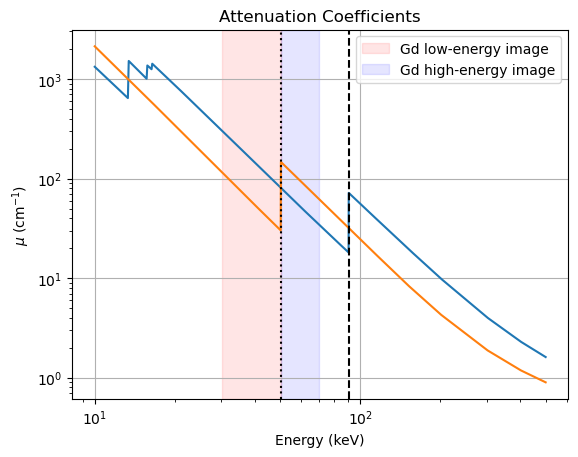

In [4]:
# Get attenuation coefficient for Bismuth

mu_bi=fc.get_mu(z=83)
# Get attenuation coefficient for Gadolinium
mu_gd=fc.get_mu(z=64)

energies = np.linspace(10, 500, 5000)

mu_bismuth = [mu_bi(energy) for energy in energies]
mu_gadolinium = [mu_gd(energy) for energy in energies]

# Add the k-edge energies to the plot
k_bi = 90.5
k_gd = 50.2

plt.figure()
plt.title('Attenuation Coefficients')
plt.loglog(energies, mu_bismuth)
plt.loglog(energies, mu_gadolinium)
plt.axvline(k_gd, color='k', linestyle=':')

plt.axvline(k_bi, color='k', linestyle='--')
# Make a light red box around the k-edges 
plt.axvspan(k_gd-20, k_gd, color='r', alpha=0.1, label='Gd low-energy image')
plt.axvspan(k_gd, k_gd + 20, color='b', alpha=0.1, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('$\mu$ (cm$^{-1}$)')
plt.legend()
plt.grid()

# Save the plo
# plt.savefig('attenuation_coefficients_bi_gd_labelled_regions.png', dpi=300)

In [4]:
import spekpy as sp

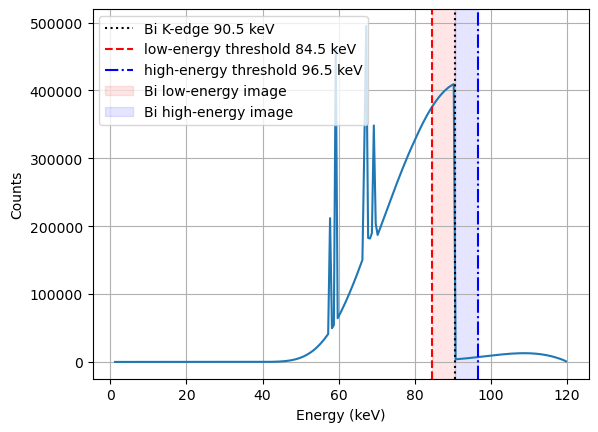

In [5]:
s = sp.Spek(120,14)
# s.filter('Al',6)
s.filter('Bi',0.89)

xx, yy = s.get_spectrum()

plt.figure()
plt.plot(xx, yy)
# plt.plot(xx2, yy2)
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
plt.axvline(k_bi, color='k', linestyle=':',label=f'Bi K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--', label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_bi + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_bi-6, k_bi, color='r', alpha=0.1, label='Bi low-energy image')
plt.axvspan(k_bi, k_bi + 6, color='b', alpha=0.1, label='Bi high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()

# Save the plot
# plt.savefig('spectra_bi_gd.png', dpi=300)

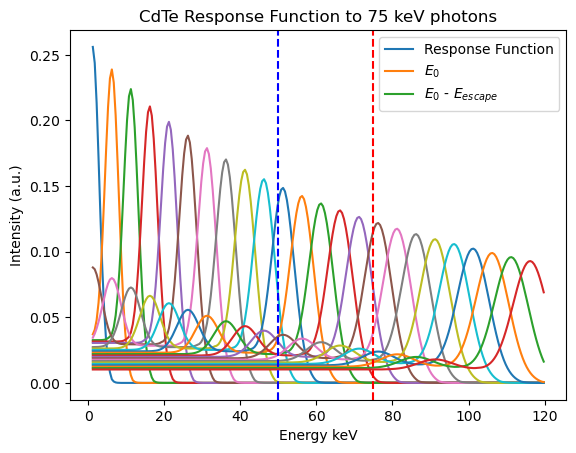

In [9]:
# %%

import math
import numpy as np
import matplotlib.pyplot as plt

# Constants
a1 = 0.5
a2 = 0.015  # Unit is keV^-1, assuming this is the value
a3 = 0.035  # Unit is keV^-1, assuming this is the value
a4 = 0.213e-3  # Unit is keV^-2, assuming this is the value
a5 = 1.64  # Unit is keV, assuming this is the value
a6 = 0.025

# Escape photon energy for CdTe (assumed to be 25 keV)
Ee = 25

# Function to calculate c2(E)


def c2(E, Ee):
    if E >= Ee:
        return a1 * np.exp(-(a2 * E))
    else:
        return 0

# Function to calculate c3(E)


def c3(E):
    return a3 - a4 * E

# Function to calculate sigma(E)


def sigma(E):
    return a5 + a6 * E

# Function to calculate B(U, E)


def B(U, E):
    Bs = []
    for u in U:
        sigma1 = sigma(E)
        if u < (E - 3 * sigma1):
            Bs.append(c3(E))
        elif E - 3 * sigma1 <= u <= E + 3 * sigma1:
            # Linearly ramped down to zero within the width of 6sigma1
            slope = -c3(E) / (6 * sigma1)
            intercept = - slope * (E + 3 * sigma1)
            Bs.append(slope * (u) + intercept)
        else:
            Bs.append(0)

    # print(intercept, slope)
    return Bs


def R(U, E):
    # Define constants
    # c1 = 1  # Assuming c1 is 1, change if needed
    # c2 = 1  # Assuming c2 is 1, change if needed
    # Er = 0  # Assuming Er is 0, change if needed
    # B = 0   # Assuming B(U, E) is 0, change if needed

    # # Define variables
    # sigma1 = 1  # Assuming sigma1(E) is 1, change if needed
    # sigma2 = 1  # Assuming sigma2(E) is 1, change if needed

    sig = sigma(E)

    c1 = 1
    # Calculation
    term1 = (1 / (math.sqrt(2 * math.pi) * sig)) * \
        np.exp(-((U - E) ** 2) / (2 * sig ** 2))
    term2 = (c2(E, Ee) / (math.sqrt(2 * math.pi) * sig)) * \
        np.exp(-((U - (E - Ee)) ** 2) / (2 * sig ** 2))

    # print(term1, term2)
    # print(B(U, E))

    return c1*(term1 + term2) + B(U, E)


# Example usage
U_value = xx # Change U_value as needed
E_value = 75   # Change E_value as needed

responses = []

for e in xx:
    responses.append(R(U_value, e))

# Plot the response function
plt.figure()
plt.title('CdTe Response Function to 75 keV photons')
plt.plot(U_value, np.array(responses[::10]).T)
plt.xlabel('Energy keV')
plt.ylabel('Intensity (a.u.)')
# add a red dotted line at 75 kev
plt.axvline(x=75, color='r', linestyle='--')
# add a blue dotted line at 25 kev
plt.axvline(x=75-25, color='b', linestyle='--')
plt.legend(['Response Function', '$E_0$', '$E_0$ - $E_{escape}$'])
plt.savefig('response_function.png',dpi=300);


In [10]:
energy_responses = []

for ii, y in enumerate(yy):

    energy_responses.append(y * (np.array(responses[ii]).T/np.sum(responses[ii])))

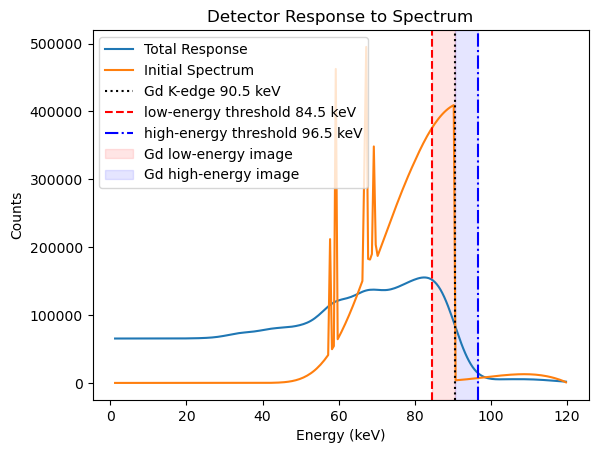

In [130]:
from cProfile import label


plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx,np.sum(np.array(energy_responses).T,axis=1),label='Total Response')
plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_bi, color='k', linestyle=':',label=f'Gd K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--', label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_bi + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_bi-6, k_bi, color='r', alpha=0.1, label='Gd low-energy image')
plt.axvspan(k_bi, k_bi + 6, color='b', alpha=0.1, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()

1217840.6350720217 93670.97312029972
97150.53628212273 549743.9551001131
21.255199646588064 21.95983736276807


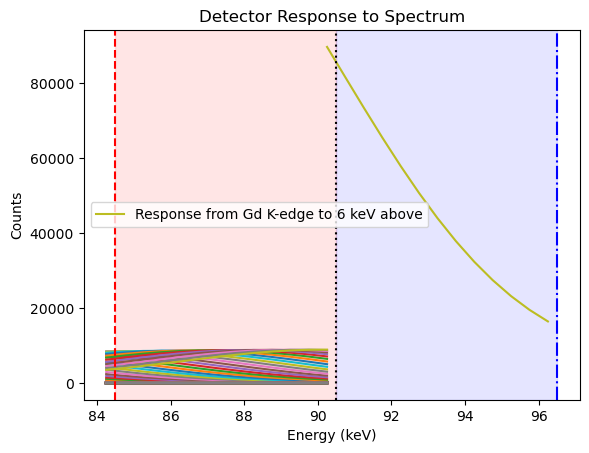

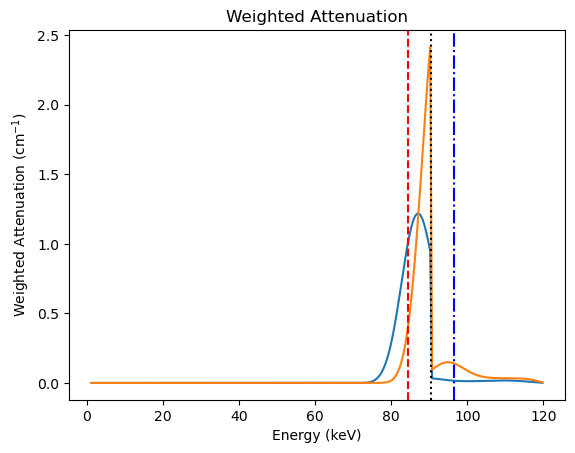

In [19]:
from cProfile import label

from networkx import second_order_centrality

ind_44 = np.argmin(np.abs(xx-(k_bi-6)))
ind_k_bi = np.argmin(np.abs(xx-k_bi))
ind_k_bi_high = np.argmin(np.abs(xx-(k_bi+6)))

# ind_44 = np.argmin(np.abs(xx-44))
# ind_k_bi = np.argmin(np.abs(xx-k_bi))
# ind_k_bi_high = np.argmin(np.abs(xx-(k_bi+6)))

plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx[ind_44:ind_k_bi+1],np.array(energy_responses[:]).T[ind_44:ind_k_bi+1])#,label='Response from 44 keV to Gd K-edge')
plt.plot(xx[ind_k_bi:ind_k_bi_high+1],np.sum(np.array(energy_responses[:]).T,axis=1)[ind_k_bi:ind_k_bi_high+1],label='Response from Gd K-edge to 6 keV above')
# plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_bi, color='k', linestyle=':')#,label=f'Gd K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--')#, label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.')#, label=f'high-energy threshold {k_bi + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_bi-6, k_bi, color='r', alpha=0.1)#, label='Gd low-energy image')
plt.axvspan(k_bi, k_bi + 6, color='b', alpha=0.1)#, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()


contribution_44_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_bi+1]).T,axis=1)[ind_44:ind_k_bi+1])
contribution_gd_to_6_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_k_bi:ind_k_bi_high+1]).T,axis=1)[ind_44:ind_k_bi+1])

print(contribution_44_to_gd_44_to_Gd, contribution_gd_to_6_44_to_Gd)

contribution_gd_to_6_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_k_bi:ind_k_bi_high+1]).T,axis=1)[ind_k_bi:ind_k_bi_high+1])
contribution_44_to_gd_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_bi+1]).T,axis=1)[ind_k_bi:ind_k_bi_high+1])

print(contribution_gd_to_6_gd_to_6, contribution_44_to_gd_gd_to_6)

contribution_low_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[:ind_k_bi+1]).T,axis=1)[ind_44:ind_k_bi+1])

weighted_attenuation_low = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_44:ind_k_bi+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_low.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_44:ind_k_bi+1])/total_signal)

weighted_attenuation_high = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_k_bi:ind_k_bi_high+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_high.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_k_bi:ind_k_bi_high+1])/total_signal)

plt.figure()
plt.title('Weighted Attenuation')
plt.plot(xx, weighted_attenuation_low)
plt.plot(xx, weighted_attenuation_high)
plt.axvline(k_bi, color='k', linestyle=':',label=f'Gd K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--', label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_bi + 6} keV')

plt.xlabel('Energy (keV)')
plt.ylabel('Weighted Attenuation (cm$^{-1}$)')
print(np.sum(weighted_attenuation_low), np.sum(weighted_attenuation_high))

## Bismuth High

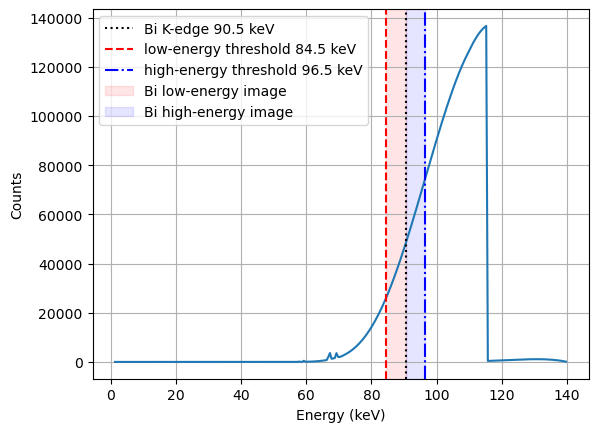

In [20]:
s = sp.Spek(140,14)
# s.filter('Al',6)
s.filter('U',0.89)

xx, yy = s.get_spectrum()

plt.figure()
plt.plot(xx, yy)
# plt.plot(xx2, yy2)
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
plt.axvline(k_bi, color='k', linestyle=':',label=f'Bi K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--', label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_bi + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_bi-6, k_bi, color='r', alpha=0.1, label='Bi low-energy image')
plt.axvspan(k_bi, k_bi + 6, color='b', alpha=0.1, label='Bi high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()

# Save the plot
# plt.savefig('spectra_bi_gd.png', dpi=300)

0.021696686767638994 -0.0034638494141111943
0.023311911315268503 -0.0034275921801534283
0.02489208096904938 -0.0033918693195775004
0.026437965039014875 -0.003356669105096318
0.02795031048777536 -0.0033219801500847254
0.029429842736121127 -0.0032877913962989667
0.030877266434025292 -0.0032540921021235983
0.03229326619876807 -0.0032208718313195936
0.03367850732180663 -0.003188120442248883
0.03503363644592385 -0.0031558280775519742
0.036359282214103464 -0.0031239851542565534
0.03765605589149966 -0.0030925823542962455
0.03892455196179365 -0.003061610615419813
0.04016534869915928 -0.003031061122472166
0.041379008716993904 -0.0030009252990295643
0.04256607949450797 -0.0029711947993723386
0.04372709388220887 -0.002941861500779337
0.04486257058725946 -0.002912917496129175
0.045973014639639646 -0.0028843550867941117
0.04705891783999127 -0.0028561667758131414
0.04812075918998049 -0.0028283452613315986
0.049159005305968555 -0.002800883430295196
0.050174110816741606 -0.0027737743523870693
0.051166

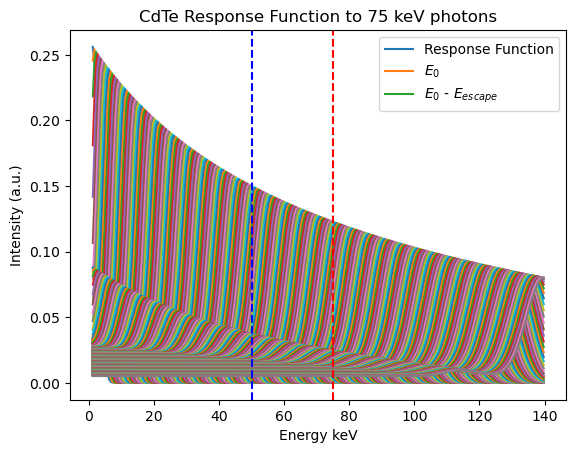

In [21]:
# %%

import math
import numpy as np
import matplotlib.pyplot as plt

# Constants
a1 = 0.5
a2 = 0.015  # Unit is keV^-1, assuming this is the value
a3 = 0.035  # Unit is keV^-1, assuming this is the value
a4 = 0.213e-3  # Unit is keV^-2, assuming this is the value
a5 = 1.64  # Unit is keV, assuming this is the value
a6 = 0.025

# Escape photon energy for CdTe (assumed to be 25 keV)
Ee = 25

# Function to calculate c2(E)


def c2(E, Ee):
    if E >= Ee:
        return a1 * np.exp(-(a2 * E))
    else:
        return 0

# Function to calculate c3(E)


def c3(E):
    return a3 - a4 * E

# Function to calculate sigma(E)


def sigma(E):
    return a5 + a6 * E

# Function to calculate B(U, E)


def B(U, E):
    Bs = []
    for u in U:
        sigma1 = sigma(E)
        if u < (E - 3 * sigma1):
            Bs.append(c3(E))
        elif E - 3 * sigma1 <= u <= E + 3 * sigma1:
            # Linearly ramped down to zero within the width of 6sigma1
            slope = -c3(E) / (6 * sigma1)
            intercept = - slope * (E + 3 * sigma1)
            Bs.append(slope * (u) + intercept)
        else:
            Bs.append(0)

    print(intercept, slope)
    return Bs


def R(U, E):
    # Define constants
    # c1 = 1  # Assuming c1 is 1, change if needed
    # c2 = 1  # Assuming c2 is 1, change if needed
    # Er = 0  # Assuming Er is 0, change if needed
    # B = 0   # Assuming B(U, E) is 0, change if needed

    # # Define variables
    # sigma1 = 1  # Assuming sigma1(E) is 1, change if needed
    # sigma2 = 1  # Assuming sigma2(E) is 1, change if needed

    sig = sigma(E)

    c1 = 1
    # Calculation
    term1 = (1 / (math.sqrt(2 * math.pi) * sig)) * \
        np.exp(-((U - E) ** 2) / (2 * sig ** 2))
    term2 = (c2(E, Ee) / (math.sqrt(2 * math.pi) * sig)) * \
        np.exp(-((U - (E - Ee)) ** 2) / (2 * sig ** 2))

    # print(term1, term2)
    # print(B(U, E))

    return c1*(term1 + term2) + B(U, E)


# Example usage
U_value = xx # Change U_value as needed
E_value = 75   # Change E_value as needed

responses = []

for e in xx:
    responses.append(R(U_value, e))

# Plot the response function
plt.figure()
plt.title('CdTe Response Function to 75 keV photons')
plt.plot(U_value, np.array(responses).T)
plt.xlabel('Energy keV')
plt.ylabel('Intensity (a.u.)')
# add a red dotted line at 75 kev
plt.axvline(x=75, color='r', linestyle='--')
# add a blue dotted line at 25 kev
plt.axvline(x=75-25, color='b', linestyle='--')
plt.legend(['Response Function', '$E_0$', '$E_0$ - $E_{escape}$'])
plt.savefig('response_function.png',dpi=300)


In [22]:
energy_responses = []

for ii, y in enumerate(yy):

    energy_responses.append(y * (np.array(responses[ii]).T/np.sum(responses[ii])))


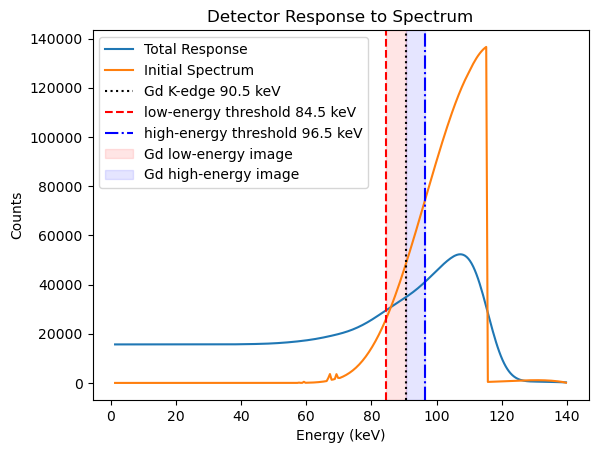

In [23]:
from cProfile import label


plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx,np.sum(np.array(energy_responses).T,axis=1),label='Total Response')
plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_bi, color='k', linestyle=':',label=f'Gd K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--', label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_bi + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_bi-6, k_bi, color='r', alpha=0.1, label='Gd low-energy image')
plt.axvspan(k_bi, k_bi + 6, color='b', alpha=0.1, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()

110301.60063421846 95253.63885455429
182337.05472983443 53963.60339902795
42.79682094127072 52.70744720094593


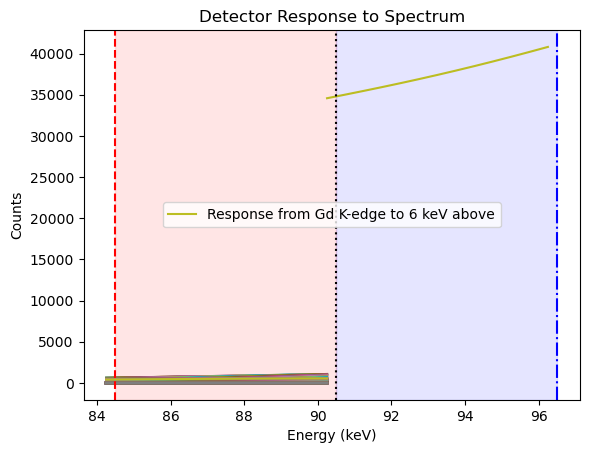

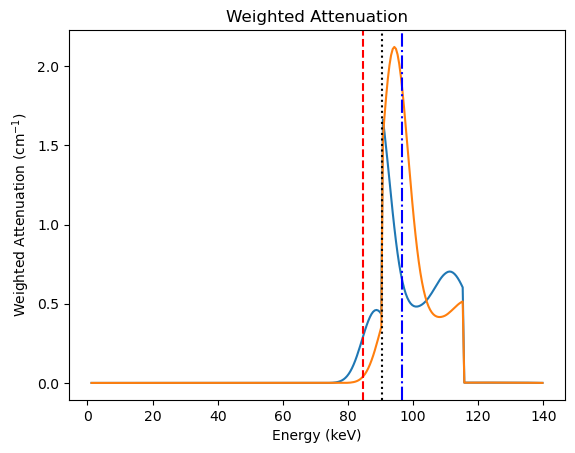

In [24]:

from cProfile import label

from networkx import second_order_centrality

ind_44 = np.argmin(np.abs(xx-(k_bi-6)))
ind_k_bi = np.argmin(np.abs(xx-k_bi))
ind_k_bi_high = np.argmin(np.abs(xx-(k_bi+6)))

# ind_44 = np.argmin(np.abs(xx-44))
# ind_k_bi = np.argmin(np.abs(xx-k_bi))
# ind_k_bi_high = np.argmin(np.abs(xx-(k_bi+6)))

plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx[ind_44:ind_k_bi+1],np.array(energy_responses[:]).T[ind_44:ind_k_bi+1])#,label='Response from 44 keV to Gd K-edge')
plt.plot(xx[ind_k_bi:ind_k_bi_high+1],np.sum(np.array(energy_responses[:]).T,axis=1)[ind_k_bi:ind_k_bi_high+1],label='Response from Gd K-edge to 6 keV above')
# plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_bi, color='k', linestyle=':')#,label=f'Gd K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--')#, label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.')#, label=f'high-energy threshold {k_bi + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_bi-6, k_bi, color='r', alpha=0.1)#, label='Gd low-energy image')
plt.axvspan(k_bi, k_bi + 6, color='b', alpha=0.1)#, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()


contribution_44_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_bi+1]).T,axis=1)[ind_44:ind_k_bi+1])
contribution_gd_to_6_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_k_bi:ind_k_bi_high+1]).T,axis=1)[ind_44:ind_k_bi+1])

print(contribution_44_to_gd_44_to_Gd, contribution_gd_to_6_44_to_Gd)

contribution_gd_to_6_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_k_bi:ind_k_bi_high+1]).T,axis=1)[ind_k_bi:ind_k_bi_high+1])
contribution_44_to_gd_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_bi+1]).T,axis=1)[ind_k_bi:ind_k_bi_high+1])

print(contribution_gd_to_6_gd_to_6, contribution_44_to_gd_gd_to_6)

contribution_low_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[:ind_k_bi+1]).T,axis=1)[ind_44:ind_k_bi+1])

weighted_attenuation_low = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_44:ind_k_bi+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_low.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_44:ind_k_bi+1])/total_signal)

weighted_attenuation_high = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_k_bi:ind_k_bi_high+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_high.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_k_bi:ind_k_bi_high+1])/total_signal)

plt.figure()
plt.title('Weighted Attenuation')
plt.plot(xx, weighted_attenuation_low)
plt.plot(xx, weighted_attenuation_high)
plt.axvline(k_bi, color='k', linestyle=':',label=f'Gd K-edge {k_bi} keV')
plt.axvline(k_bi - 6, color='r', linestyle='--', label=f'low-energy threshold {k_bi - 6} keV')
plt.axvline(k_bi + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_bi + 6} keV')

plt.xlabel('Energy (keV)')
plt.ylabel('Weighted Attenuation (cm$^{-1}$)')
print(np.sum(weighted_attenuation_low), np.sum(weighted_attenuation_high))

## Gadolinium

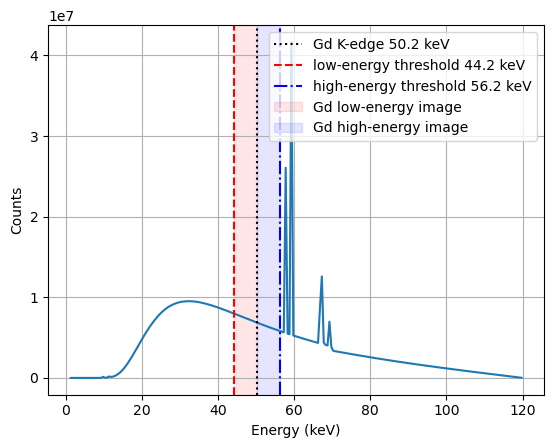

In [26]:
s = sp.Spek(120,14)
s.filter('Al',1)
# s.filter('Bi',0.89)

xx, yy = s.get_spectrum()

plt.figure()
plt.plot(xx, yy)
# plt.plot(xx2, yy2)
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
plt.axvline(k_gd, color='k', linestyle=':',label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_gd - 6, color='r', linestyle='--', label=f'low-energy threshold {k_gd - 6} keV')
plt.axvline(k_gd + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_gd + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_gd-6, k_gd, color='r', alpha=0.1, label='Gd low-energy image')
plt.axvspan(k_gd, k_gd + 6, color='b', alpha=0.1, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()

# Save the plot
# plt.savefig('spectra_bi_gd.png', dpi=300)

0.021696686767638994 -0.0034638494141111943
0.023311911315268503 -0.0034275921801534283
0.02489208096904938 -0.0033918693195775004
0.026437965039014875 -0.003356669105096318
0.02795031048777536 -0.0033219801500847254
0.029429842736121127 -0.0032877913962989667
0.030877266434025292 -0.0032540921021235983
0.03229326619876807 -0.0032208718313195936
0.03367850732180663 -0.003188120442248883
0.03503363644592385 -0.0031558280775519742
0.036359282214103464 -0.0031239851542565534
0.03765605589149966 -0.0030925823542962455
0.03892455196179365 -0.003061610615419813
0.04016534869915928 -0.003031061122472166
0.041379008716993904 -0.0030009252990295643
0.04256607949450797 -0.0029711947993723386
0.04372709388220887 -0.002941861500779337
0.04486257058725946 -0.002912917496129175
0.045973014639639646 -0.0028843550867941117
0.04705891783999127 -0.0028561667758131414
0.04812075918998049 -0.0028283452613315986
0.049159005305968555 -0.002800883430295196
0.050174110816741606 -0.0027737743523870693
0.051166

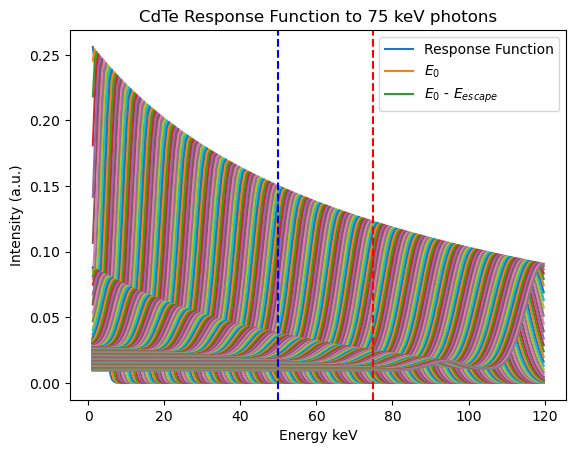

In [27]:
# %%

import math
import numpy as np
import matplotlib.pyplot as plt

# Constants
a1 = 0.5
a2 = 0.015  # Unit is keV^-1, assuming this is the value
a3 = 0.035  # Unit is keV^-1, assuming this is the value
a4 = 0.213e-3  # Unit is keV^-2, assuming this is the value
a5 = 1.64  # Unit is keV, assuming this is the value
a6 = 0.025

# Escape photon energy for CdTe (assumed to be 25 keV)
Ee = 25

# Function to calculate c2(E)


def c2(E, Ee):
    if E >= Ee:
        return a1 * np.exp(-(a2 * E))
    else:
        return 0

# Function to calculate c3(E)


def c3(E):
    return a3 - a4 * E

# Function to calculate sigma(E)


def sigma(E):
    return a5 + a6 * E

# Function to calculate B(U, E)


def B(U, E):
    Bs = []
    for u in U:
        sigma1 = sigma(E)
        if u < (E - 3 * sigma1):
            Bs.append(c3(E))
        elif E - 3 * sigma1 <= u <= E + 3 * sigma1:
            # Linearly ramped down to zero within the width of 6sigma1
            slope = -c3(E) / (6 * sigma1)
            intercept = - slope * (E + 3 * sigma1)
            Bs.append(slope * (u) + intercept)
        else:
            Bs.append(0)

    print(intercept, slope)
    return Bs


def R(U, E):
    # Define constants
    # c1 = 1  # Assuming c1 is 1, change if needed
    # c2 = 1  # Assuming c2 is 1, change if needed
    # Er = 0  # Assuming Er is 0, change if needed
    # B = 0   # Assuming B(U, E) is 0, change if needed

    # # Define variables
    # sigma1 = 1  # Assuming sigma1(E) is 1, change if needed
    # sigma2 = 1  # Assuming sigma2(E) is 1, change if needed

    sig = sigma(E)

    c1 = 1
    # Calculation
    term1 = (1 / (math.sqrt(2 * math.pi) * sig)) * \
        np.exp(-((U - E) ** 2) / (2 * sig ** 2))
    term2 = (c2(E, Ee) / (math.sqrt(2 * math.pi) * sig)) * \
        np.exp(-((U - (E - Ee)) ** 2) / (2 * sig ** 2))

    # print(term1, term2)
    # print(B(U, E))

    return c1*(term1 + term2) + B(U, E)


# Example usage
U_value = xx # Change U_value as needed
E_value = 75   # Change E_value as needed

responses = []

for e in xx:
    responses.append(R(U_value, e))

# Plot the response function
plt.figure()
plt.title('CdTe Response Function to 75 keV photons')
plt.plot(U_value, np.array(responses).T)
plt.xlabel('Energy keV')
plt.ylabel('Intensity (a.u.)')
# add a red dotted line at 75 kev
plt.axvline(x=75, color='r', linestyle='--')
# add a blue dotted line at 25 kev
plt.axvline(x=75-25, color='b', linestyle='--')
plt.legend(['Response Function', '$E_0$', '$E_0$ - $E_{escape}$'])
plt.savefig('response_function.png',dpi=300)


In [28]:
energy_responses = []

for ii, y in enumerate(yy):

    energy_responses.append(y * (np.array(responses[ii]).T/np.sum(responses[ii])))


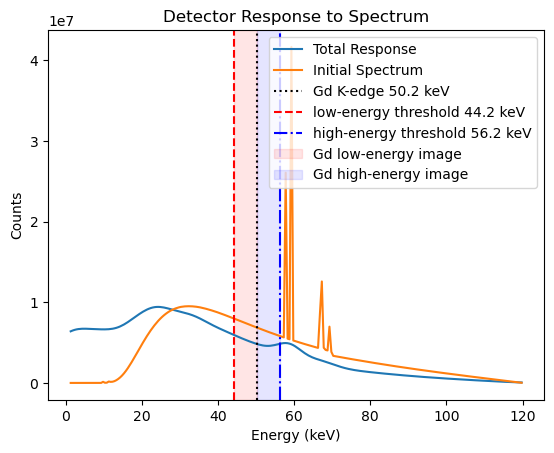

In [29]:
from cProfile import label


plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx,np.sum(np.array(energy_responses).T,axis=1),label='Total Response')
plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_gd, color='k', linestyle=':',label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_gd - 6, color='r', linestyle='--', label=f'low-energy threshold {k_gd - 6} keV')
plt.axvline(k_gd + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_gd + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_gd-6, k_gd, color='r', alpha=0.1, label='Gd low-energy image')
plt.axvspan(k_gd, k_gd + 6, color='b', alpha=0.1, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()

29625481.26409338 11768805.836442623
23948457.169218104 8997346.555567687
79.33656186614463 60.73602805536197


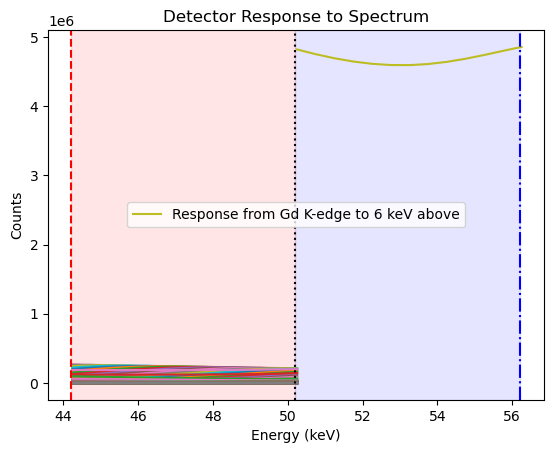

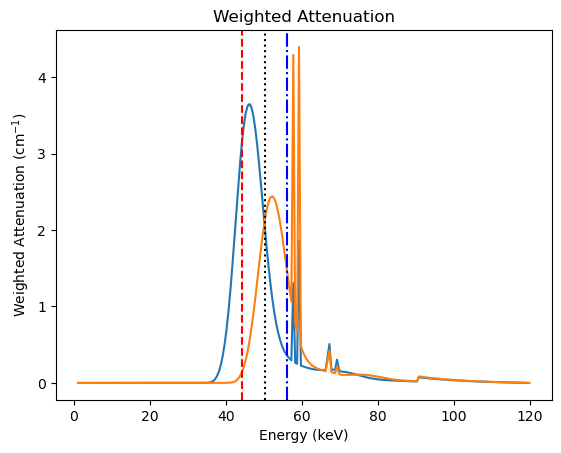

In [31]:

from cProfile import label

from networkx import second_order_centrality

ind_44 = np.argmin(np.abs(xx-(k_gd-6)))
ind_k_gd = np.argmin(np.abs(xx-k_gd))
ind_k_gd_high = np.argmin(np.abs(xx-(k_gd+6)))

# ind_44 = np.argmin(np.abs(xx-44))
# ind_k_gd = np.argmin(np.abs(xx-k_gd))
# ind_k_gd_high = np.argmin(np.abs(xx-(k_gd+6)))

plt.figure()
plt.title('Detector Response to Spectrum')
plt.plot(xx[ind_44:ind_k_gd+1],np.array(energy_responses[:]).T[ind_44:ind_k_gd+1])#,label='Response from 44 keV to Gd K-edge')
plt.plot(xx[ind_k_gd:ind_k_gd_high+1],np.sum(np.array(energy_responses[:]).T,axis=1)[ind_k_gd:ind_k_gd_high+1],label='Response from Gd K-edge to 6 keV above')
# plt.plot(xx,yy,label='Initial Spectrum')
plt.axvline(k_gd, color='k', linestyle=':')#,label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_gd - 6, color='r', linestyle='--')#, label=f'low-energy threshold {k_gd - 6} keV')
plt.axvline(k_gd + 6, color='b', linestyle='-.')#, label=f'high-energy threshold {k_gd + 6} keV')
# Label the regions before and after the gadolinium k-edge 
plt.axvspan(k_gd-6, k_gd, color='r', alpha=0.1)#, label='Gd low-energy image')
plt.axvspan(k_gd, k_gd + 6, color='b', alpha=0.1)#, label='Gd high-energy image')
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.legend()


contribution_44_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_gd+1]).T,axis=1)[ind_44:ind_k_gd+1])
contribution_gd_to_6_44_to_Gd = np.sum(np.sum(np.array(energy_responses[ind_k_gd:ind_k_gd_high+1]).T,axis=1)[ind_44:ind_k_gd+1])

print(contribution_44_to_gd_44_to_Gd, contribution_gd_to_6_44_to_Gd)

contribution_gd_to_6_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_k_gd:ind_k_gd_high+1]).T,axis=1)[ind_k_gd:ind_k_gd_high+1])
contribution_44_to_gd_gd_to_6 = np.sum(np.sum(np.array(energy_responses[ind_44:ind_k_gd+1]).T,axis=1)[ind_k_gd:ind_k_gd_high+1])

print(contribution_gd_to_6_gd_to_6, contribution_44_to_gd_gd_to_6)

contribution_low_to_gd_44_to_Gd = np.sum(np.sum(np.array(energy_responses[:ind_k_gd+1]).T,axis=1)[ind_44:ind_k_gd+1])

weighted_attenuation_low = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_44:ind_k_gd+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_low.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_44:ind_k_gd+1])/total_signal)

weighted_attenuation_high = []
total_signal = np.sum(np.sum(np.array(energy_responses).T,axis=1)[ind_k_gd:ind_k_gd_high+1])

for ii, e in enumerate(xx):
    mu = mu_bi(e)
    weighted_attenuation_high.append(mu * np.sum(np.array(energy_responses[ii]).T[ind_k_gd:ind_k_gd_high+1])/total_signal)

plt.figure()
plt.title('Weighted Attenuation')
plt.plot(xx, weighted_attenuation_low)
plt.plot(xx, weighted_attenuation_high)
plt.axvline(k_gd, color='k', linestyle=':',label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_gd - 6, color='r', linestyle='--', label=f'low-energy threshold {k_gd - 6} keV')
plt.axvline(k_gd + 6, color='b', linestyle='-.', label=f'high-energy threshold {k_gd + 6} keV')

plt.xlabel('Energy (keV)')
plt.ylabel('Weighted Attenuation (cm$^{-1}$)')
print(np.sum(weighted_attenuation_low), np.sum(weighted_attenuation_high))

37 98


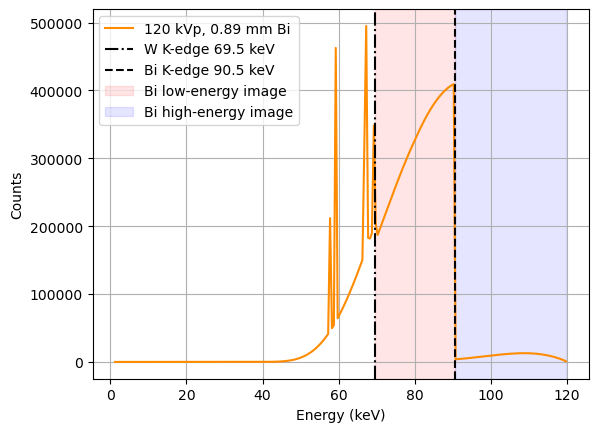

In [27]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

s2 = sp.Spek(120,14)
# s2.filter('Al',4)
s2.filter('Bi',0.89)
# s2.filter('Cu',2)

xx2, yy2 = s2.get_spectrum()

k_20 = 20
k_W = 69.5
# Calculate the percent of the fluence between the k-edges 
fluence_to_gd_120 = np.sum(yy[k_20_index:k_gd_index]) / np.sum(yy)
fluence_to_gd_140 = np.sum(yy2[k_20_index:k_gd_index]) / np.sum(yy2)
fluence_gd_to_W_120 = np.sum(yy[k_gd_index:k_W_index]) / np.sum(yy)
fluence_gd_to_W_140 = np.sum(yy2[k_gd_index:k_W_index]) / np.sum(yy2)
fluence_W_to_bi_120 = np.sum(yy[k_W_index:k_bi_index]) / np.sum(yy)
fluence_W_to_bi_140 = np.sum(yy2[k_W_index:k_bi_index]) / np.sum(yy2)
fluence_bi_120 = np.sum(yy[k_bi_index:]) / np.sum(yy)
fluence_bi_140 = np.sum(yy2[k_bi_index:]) / np.sum(yy2)

# Find the mean energy in each num_regions
mean_energy_120 = np.mean(xx*(yy/np.sum(yy)))
# mean_energy_140 = np.mean(xx2*(yy2/np.sum(yy2)))
print(k_20_index,k_gd_index)
# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_gd_120 = np.sum(xx[k_20_index:k_gd_index]*(yy[k_20_index:k_gd_index]/np.sum(yy[k_20_index:k_gd_index])))
mean_energy_to_gd_140 = np.sum(xx2[k_20_index:k_gd_index]*(yy2[k_20_index:k_gd_index]/np.sum(yy2[k_20_index:k_gd_index])))
mean_energy_gd_to_W_120 = np.sum(xx[k_gd_index:k_W_index]*(yy[k_gd_index:k_W_index]/np.sum(yy[k_gd_index:k_W_index])))
mean_energy_gd_to_W_140 = np.sum(xx2[k_gd_index:k_W_index]*(yy2[k_gd_index:k_W_index]/np.sum(yy2[k_gd_index:k_W_index])))
mean_energy_W_to_bi_120 = np.sum(xx[k_W_index:k_bi_index]*(yy[k_W_index:k_bi_index]/np.sum(yy[k_W_index:k_bi_index])))
mean_energy_W_to_bi_140 = np.sum(xx2[k_W_index:k_bi_index]*(yy2[k_W_index:k_bi_index]/np.sum(yy2[k_W_index:k_bi_index])))
mean_energy_bi_120 = np.sum(xx[k_bi_index:]*(yy[k_bi_index:]/np.sum(yy[k_bi_index:])))
mean_energy_bi_140 = np.sum(xx2[k_bi_index:]*(yy2[k_bi_index:]/np.sum(yy2[k_bi_index:])))
                                
plt.figure()
# plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='120 kVp, 0.89 mm Bi',c='darkorange')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
# plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
# plt.axvline(k_gd, color='k', linestyle=':', label=f'Gd K-edge {k_gd} keV')
plt.axvline(69.5, color='k', linestyle='-.', label=f'W K-edge 69.5 keV')
plt.axvline(k_bi, color='k', linestyle='--', label=f'Bi K-edge {k_bi} keV')
mu_at_mean_energy_to_gd_120 = mu_gd(mean_energy_to_gd_120)
mu_at_mean_energy_to_gd_140 = mu_bi(mean_energy_to_gd_140)
mu_at_mean_energy_gd_to_W_120 = mu_gd(mean_energy_gd_to_W_120)
mu_at_mean_energy_gd_to_W_140 = mu_bi(mean_energy_gd_to_W_140)
mu_at_mean_energy_W_to_bi_120 = mu_bi(mean_energy_W_to_bi_120)
mu_at_mean_energy_W_to_bi_140 = mu_bi(mean_energy_W_to_bi_140)
mu_at_mean_energy_bi_120 = mu_bi(mean_energy_bi_120)
mu_at_mean_energy_bi_140 = mu_bi(mean_energy_bi_140)

# show the percent of the fluence between the k-edges in each num_regions
# plt.text((k_gd+20)/2, 0.5*max(yy), f'$\mu$\n{mu_at_mean_energy_to_gd_120:.2f}\ncm$^{-1}$',color='r',ha='center',fontsize=14)
# plt.text((k_gd+k_W)/2, 0.5*max(yy), f'$\mu$\n{mu_at_mean_energy_gd_to_W_120:.2f}\ncm$^{-1}$',color='b',ha='center',fontsize=14)
# plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'$\mu$\n{mu_at_mean_energy_W_to_bi_120:.2f}\ncm$^{-1}$',
#          color='r',ha='center',fontsize=14)
# plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'$\mu$\n{mu_at_mean_energy_bi_120:.2f}\ncm$^{-1}$',
#          color='b',ha='center',fontsize=14)


# show the percent of the fluence between the k-edges in each num_regions
# plt.text((k_gd+20)/2, 0.5*max(yy), f'{mean_energy_to_gd_120:.2f}\nkeV',color='r',ha='center',fontsize=14)
# plt.text((k_gd+k_W)/2, 0.5*max(yy), f'{mean_energy_gd_to_W_120:.2f}\nkeV',color='b',ha='center',fontsize=14)
# plt.text((k_W+k_bi)/2, 0.5*max(yy), f'{mean_energy_W_to_bi_120:.2f}\nkeV',color='cornflowerblue',ha='center')
# plt.text((k_bi+max(xx))/2, 0.5*max(yy), f'{mean_energy_bi_120:.2f}\nkeV',color='cornflowerblue',ha='center')

# plt.text((k_gd+20)/2, 0.5*max(yy2), f'{mean_energy_to_gd_140:.2f}\nkeV',color='orange',ha='center')
# plt.text((k_gd+k_W)/2, 0.5*max(yy2), f'{mean_energy_gd_to_W_140:.2f}\nkeV',color='red',ha='center')
# plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'{mean_energy_W_to_bi_140:.2f}\nkeV',color='orange',ha='center')
# plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'{mean_energy_bi_140:.2f}\nkeV',color='orange',ha='center')

# plot the region between k_20 and k_gd in red and the next region in blue
# plt.axvspan(k_20, k_gd, color='r', alpha=0.1, label='Gd low-energy image')
# plt.axvspan(k_gd, k_W, color='b', alpha=0.1, label='Gd high-energy image')
plt.axvspan(k_W, k_bi, color='r', alpha=0.1, label='Bi low-energy image')
plt.axvspan(k_bi, max(xx2), color='b', alpha=0.1, label='Bi high-energy image')

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()

# Save the plot
plt.savefig('spectra_bi_gd_mu_140_low.png', dpi=300)

37 98


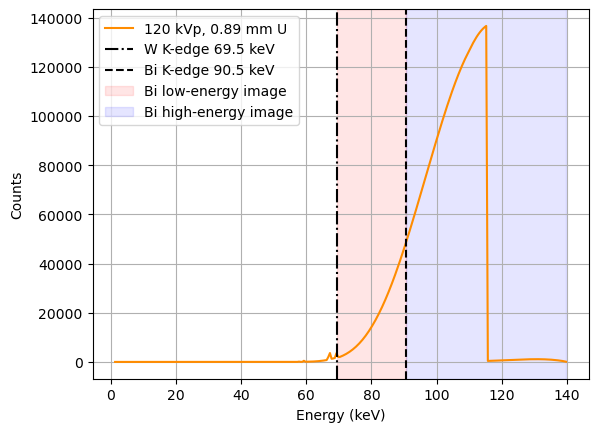

In [25]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

s2 = sp.Spek(140,14)
# s2.filter('Al',4)
s2.filter('U',0.89)
# s2.filter('Cu',2)

xx2, yy2 = s2.get_spectrum()

k_20 = 20
k_W = 69.5
# Calculate the percent of the fluence between the k-edges 
fluence_to_gd_120 = np.sum(yy[k_20_index:k_gd_index]) / np.sum(yy)
fluence_to_gd_140 = np.sum(yy2[k_20_index:k_gd_index]) / np.sum(yy2)
fluence_gd_to_W_120 = np.sum(yy[k_gd_index:k_W_index]) / np.sum(yy)
fluence_gd_to_W_140 = np.sum(yy2[k_gd_index:k_W_index]) / np.sum(yy2)
fluence_W_to_bi_120 = np.sum(yy[k_W_index:k_bi_index]) / np.sum(yy)
fluence_W_to_bi_140 = np.sum(yy2[k_W_index:k_bi_index]) / np.sum(yy2)
fluence_bi_120 = np.sum(yy[k_bi_index:]) / np.sum(yy)
fluence_bi_140 = np.sum(yy2[k_bi_index:]) / np.sum(yy2)

# Find the mean energy in each num_regions
mean_energy_120 = np.mean(xx*(yy/np.sum(yy)))
# mean_energy_140 = np.mean(xx2*(yy2/np.sum(yy2)))
print(k_20_index,k_gd_index)
# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_gd_120 = np.sum(xx[k_20_index:k_gd_index]*(yy[k_20_index:k_gd_index]/np.sum(yy[k_20_index:k_gd_index])))
mean_energy_to_gd_140 = np.sum(xx2[k_20_index:k_gd_index]*(yy2[k_20_index:k_gd_index]/np.sum(yy2[k_20_index:k_gd_index])))
mean_energy_gd_to_W_120 = np.sum(xx[k_gd_index:k_W_index]*(yy[k_gd_index:k_W_index]/np.sum(yy[k_gd_index:k_W_index])))
mean_energy_gd_to_W_140 = np.sum(xx2[k_gd_index:k_W_index]*(yy2[k_gd_index:k_W_index]/np.sum(yy2[k_gd_index:k_W_index])))
mean_energy_W_to_bi_120 = np.sum(xx[k_W_index:k_bi_index]*(yy[k_W_index:k_bi_index]/np.sum(yy[k_W_index:k_bi_index])))
mean_energy_W_to_bi_140 = np.sum(xx2[k_W_index:k_bi_index]*(yy2[k_W_index:k_bi_index]/np.sum(yy2[k_W_index:k_bi_index])))
mean_energy_bi_120 = np.sum(xx[k_bi_index:]*(yy[k_bi_index:]/np.sum(yy[k_bi_index:])))
mean_energy_bi_140 = np.sum(xx2[k_bi_index:]*(yy2[k_bi_index:]/np.sum(yy2[k_bi_index:])))
                                
plt.figure()
# plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='120 kVp, 0.89 mm U',c='darkorange')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
# plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
# plt.axvline(k_gd, color='k', linestyle=':', label=f'Gd K-edge {k_gd} keV')
plt.axvline(69.5, color='k', linestyle='-.', label=f'W K-edge 69.5 keV')
plt.axvline(k_bi, color='k', linestyle='--', label=f'Bi K-edge {k_bi} keV')
mu_at_mean_energy_to_gd_120 = mu_gd(mean_energy_to_gd_120)
mu_at_mean_energy_to_gd_140 = mu_bi(mean_energy_to_gd_140)
mu_at_mean_energy_gd_to_W_120 = mu_gd(mean_energy_gd_to_W_120)
mu_at_mean_energy_gd_to_W_140 = mu_bi(mean_energy_gd_to_W_140)
mu_at_mean_energy_W_to_bi_120 = mu_bi(mean_energy_W_to_bi_120)
mu_at_mean_energy_W_to_bi_140 = mu_bi(mean_energy_W_to_bi_140)
mu_at_mean_energy_bi_120 = mu_bi(mean_energy_bi_120)
mu_at_mean_energy_bi_140 = mu_bi(mean_energy_bi_140)

# show the percent of the fluence between the k-edges in each num_regions
# plt.text((k_gd+20)/2, 0.5*max(yy), f'$\mu$\n{mu_at_mean_energy_to_gd_120:.2f}\ncm$^{-1}$',color='r',ha='center',fontsize=14)
# plt.text((k_gd+k_W)/2, 0.5*max(yy), f'$\mu$\n{mu_at_mean_energy_gd_to_W_120:.2f}\ncm$^{-1}$',color='b',ha='center',fontsize=14)
# plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'$\mu$\n{mu_at_mean_energy_W_to_bi_120:.2f}\ncm$^{-1}$',
#          color='r',ha='center',fontsize=14)
# plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'$\mu$\n{mu_at_mean_energy_bi_120:.2f}\ncm$^{-1}$',
#          color='b',ha='center',fontsize=14)


# show the percent of the fluence between the k-edges in each num_regions
# plt.text((k_gd+20)/2, 0.5*max(yy), f'{mean_energy_to_gd_120:.2f}\nkeV',color='r',ha='center',fontsize=14)
# plt.text((k_gd+k_W)/2, 0.5*max(yy), f'{mean_energy_gd_to_W_120:.2f}\nkeV',color='b',ha='center',fontsize=14)
# plt.text((k_W+k_bi)/2, 0.5*max(yy), f'{mean_energy_W_to_bi_120:.2f}\nkeV',color='cornflowerblue',ha='center')
# plt.text((k_bi+max(xx))/2, 0.5*max(yy), f'{mean_energy_bi_120:.2f}\nkeV',color='cornflowerblue',ha='center')

# plt.text((k_gd+20)/2, 0.5*max(yy2), f'{mean_energy_to_gd_140:.2f}\nkeV',color='orange',ha='center')
# plt.text((k_gd+k_W)/2, 0.5*max(yy2), f'{mean_energy_gd_to_W_140:.2f}\nkeV',color='red',ha='center')
# plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'{mean_energy_W_to_bi_140:.2f}\nkeV',color='orange',ha='center')
# plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'{mean_energy_bi_140:.2f}\nkeV',color='orange',ha='center')

# plot the region between k_20 and k_gd in red and the next region in blue
# plt.axvspan(k_20, k_gd, color='r', alpha=0.1, label='Gd low-energy image')
# plt.axvspan(k_gd, k_W, color='b', alpha=0.1, label='Gd high-energy image')
plt.axvspan(k_W, k_bi, color='r', alpha=0.1, label='Bi low-energy image')
plt.axvspan(k_bi, max(xx2), color='b', alpha=0.1, label='Bi high-energy image')

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()

# Save the plot
plt.savefig('spectra_bi_gd_mu_140_high.png', dpi=300)

37 98


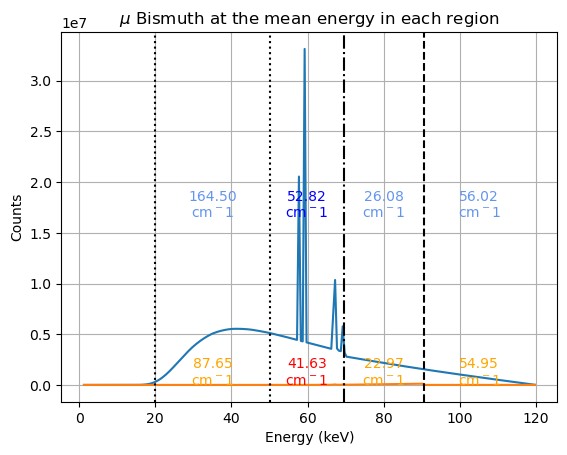

In [10]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

k_20 = 20
k_W = 69.5
# Calculate the percent of the fluence between the k-edges 
fluence_to_gd_120 = np.sum(yy[k_20_index:k_gd_index]) / np.sum(yy)
fluence_to_gd_140 = np.sum(yy2[k_20_index:k_gd_index]) / np.sum(yy2)
fluence_gd_to_W_120 = np.sum(yy[k_gd_index:k_W_index]) / np.sum(yy)
fluence_gd_to_W_140 = np.sum(yy2[k_gd_index:k_W_index]) / np.sum(yy2)
fluence_W_to_bi_120 = np.sum(yy[k_W_index:k_bi_index]) / np.sum(yy)
fluence_W_to_bi_140 = np.sum(yy2[k_W_index:k_bi_index]) / np.sum(yy2)
fluence_bi_120 = np.sum(yy[k_bi_index:]) / np.sum(yy)
fluence_bi_140 = np.sum(yy2[k_bi_index:]) / np.sum(yy2)

# Find the mean energy in each num_regions
mean_energy_120 = np.mean(xx*(yy/np.sum(yy)))
mean_energy_140 = np.mean(xx2*(yy2/np.sum(yy2)))
print(k_20_index,k_gd_index)
# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_gd_120 = np.sum(xx[k_20_index:k_gd_index]*(yy[k_20_index:k_gd_index]/np.sum(yy[k_20_index:k_gd_index])))
mean_energy_to_gd_140 = np.sum(xx2[k_20_index:k_gd_index]*(yy2[k_20_index:k_gd_index]/np.sum(yy2[k_20_index:k_gd_index])))
mean_energy_gd_to_W_120 = np.sum(xx[k_gd_index:k_W_index]*(yy[k_gd_index:k_W_index]/np.sum(yy[k_gd_index:k_W_index])))
mean_energy_gd_to_W_140 = np.sum(xx2[k_gd_index:k_W_index]*(yy2[k_gd_index:k_W_index]/np.sum(yy2[k_gd_index:k_W_index])))
mean_energy_W_to_bi_120 = np.sum(xx[k_W_index:k_bi_index]*(yy[k_W_index:k_bi_index]/np.sum(yy[k_W_index:k_bi_index])))
mean_energy_W_to_bi_140 = np.sum(xx2[k_W_index:k_bi_index]*(yy2[k_W_index:k_bi_index]/np.sum(yy2[k_W_index:k_bi_index])))
mean_energy_bi_120 = np.sum(xx[k_bi_index:]*(yy[k_bi_index:]/np.sum(yy[k_bi_index:])))
mean_energy_bi_140 = np.sum(xx2[k_bi_index:]*(yy2[k_bi_index:]/np.sum(yy2[k_bi_index:])))
                                
plt.figure()
plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='140 kVp')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
plt.axvline(k_gd, color='k', linestyle=':', label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_bi, color='k', linestyle='--', label=f'Bi K-edge {k_bi} keV')
plt.axvline(69.5, color='k', linestyle='-.', label=f'W K-edge 69.5 keV')

# mu_at_mean_energy_120 = mu_bi(mean_energy_120)
# mu_at_mean_energy_140 = mu_bi(mean_energy_140)

mu_at_mean_energy_to_gd_120 = mu_bi(mean_energy_to_gd_120)
mu_at_mean_energy_to_gd_140 = mu_bi(mean_energy_to_gd_140)
mu_at_mean_energy_gd_to_W_120 = mu_bi(mean_energy_gd_to_W_120)
mu_at_mean_energy_gd_to_W_140 = mu_bi(mean_energy_gd_to_W_140)
mu_at_mean_energy_W_to_bi_120 = mu_bi(mean_energy_W_to_bi_120)
mu_at_mean_energy_W_to_bi_140 = mu_bi(mean_energy_W_to_bi_140)
mu_at_mean_energy_bi_120 = mu_bi(mean_energy_bi_120)
mu_at_mean_energy_bi_140 = mu_bi(mean_energy_bi_140)

# show the percent of the fluence between the k-edges in each num_regions
plt.text((k_gd+20)/2, 0.5*max(yy), f'{mu_at_mean_energy_to_gd_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')
plt.text((k_gd+k_W)/2, 0.5*max(yy), f'{mu_at_mean_energy_gd_to_W_120:.2f}\ncm$^{-1}$',color='blue',ha='center')
plt.text((k_W+k_bi)/2, 0.5*max(yy), f'{mu_at_mean_energy_W_to_bi_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')
plt.text((k_bi+max(xx))/2, 0.5*max(yy), f'{mu_at_mean_energy_bi_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')

plt.text((k_gd+20)/2, 0.5*max(yy2), f'{mu_at_mean_energy_to_gd_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
plt.text((k_gd+k_W)/2, 0.5*max(yy2), f'{mu_at_mean_energy_gd_to_W_140:.2f}\ncm$^{-1}$',color='red',ha='center')
plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'{mu_at_mean_energy_W_to_bi_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'{mu_at_mean_energy_bi_140:.2f}\ncm$^{-1}$',color='orange',ha='center')

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.title('$\mu$ Bismuth at the mean energy in each region')
# plt.legend()

# Save the plot
plt.savefig('spectra_bi_gd_mu_bi.png', dpi=300)

37 98


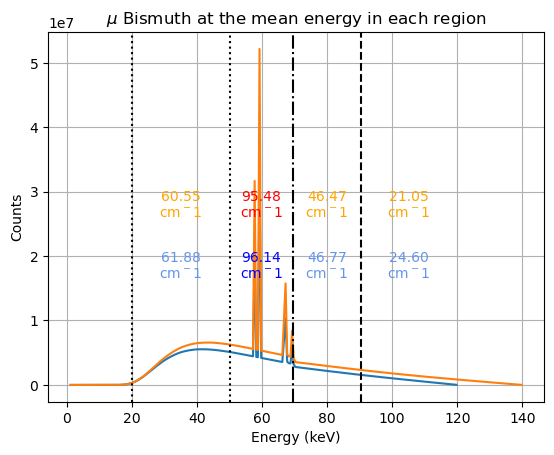

In [75]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

k_20 = 20
k_W = 69.5
# Calculate the percent of the fluence between the k-edges 
fluence_to_gd_120 = np.sum(yy[k_20_index:k_gd_index]) / np.sum(yy)
fluence_to_gd_140 = np.sum(yy2[k_20_index:k_gd_index]) / np.sum(yy2)
fluence_gd_to_W_120 = np.sum(yy[k_gd_index:k_W_index]) / np.sum(yy)
fluence_gd_to_W_140 = np.sum(yy2[k_gd_index:k_W_index]) / np.sum(yy2)
fluence_W_to_bi_120 = np.sum(yy[k_W_index:k_bi_index]) / np.sum(yy)
fluence_W_to_bi_140 = np.sum(yy2[k_W_index:k_bi_index]) / np.sum(yy2)
fluence_bi_120 = np.sum(yy[k_bi_index:]) / np.sum(yy)
fluence_bi_140 = np.sum(yy2[k_bi_index:]) / np.sum(yy2)

# Find the mean energy in each num_regions
mean_energy_120 = np.mean(xx*(yy/np.sum(yy)))
mean_energy_140 = np.mean(xx2*(yy2/np.sum(yy2)))
print(k_20_index,k_gd_index)
# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_gd_120 = np.sum(xx[k_20_index:k_gd_index]*(yy[k_20_index:k_gd_index]/np.sum(yy[k_20_index:k_gd_index])))
mean_energy_to_gd_140 = np.sum(xx2[k_20_index:k_gd_index]*(yy2[k_20_index:k_gd_index]/np.sum(yy2[k_20_index:k_gd_index])))
mean_energy_gd_to_W_120 = np.sum(xx[k_gd_index:k_W_index]*(yy[k_gd_index:k_W_index]/np.sum(yy[k_gd_index:k_W_index])))
mean_energy_gd_to_W_140 = np.sum(xx2[k_gd_index:k_W_index]*(yy2[k_gd_index:k_W_index]/np.sum(yy2[k_gd_index:k_W_index])))
mean_energy_W_to_bi_120 = np.sum(xx[k_W_index:k_bi_index]*(yy[k_W_index:k_bi_index]/np.sum(yy[k_W_index:k_bi_index])))
mean_energy_W_to_bi_140 = np.sum(xx2[k_W_index:k_bi_index]*(yy2[k_W_index:k_bi_index]/np.sum(yy2[k_W_index:k_bi_index])))
mean_energy_bi_120 = np.sum(xx[k_bi_index:]*(yy[k_bi_index:]/np.sum(yy[k_bi_index:])))
mean_energy_bi_140 = np.sum(xx2[k_bi_index:]*(yy2[k_bi_index:]/np.sum(yy2[k_bi_index:])))
                                
plt.figure()
plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='140 kVp')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
plt.axvline(k_gd, color='k', linestyle=':', label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_bi, color='k', linestyle='--', label=f'Bi K-edge {k_bi} keV')
plt.axvline(69.5, color='k', linestyle='-.', label=f'W K-edge 69.5 keV')

# mu_at_mean_energy_120 = mu_bi(mean_energy_120)
# mu_at_mean_energy_140 = mu_bi(mean_energy_140)

mu_at_mean_energy_to_gd_120 = mu_gd(mean_energy_to_gd_120)
mu_at_mean_energy_to_gd_140 = mu_gd(mean_energy_to_gd_140)
mu_at_mean_energy_gd_to_W_120 = mu_gd(mean_energy_gd_to_W_120)
mu_at_mean_energy_gd_to_W_140 = mu_gd(mean_energy_gd_to_W_140)
mu_at_mean_energy_W_to_bi_120 = mu_gd(mean_energy_W_to_bi_120)
mu_at_mean_energy_W_to_bi_140 = mu_gd(mean_energy_W_to_bi_140)
mu_at_mean_energy_bi_120 = mu_gd(mean_energy_bi_120)
mu_at_mean_energy_bi_140 = mu_gd(mean_energy_bi_140)

# show the percent of the fluence between the k-edges in each num_regions
plt.text((k_gd+20)/2, 0.5*max(yy), f'{mu_at_mean_energy_to_gd_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')
plt.text((k_gd+k_W)/2, 0.5*max(yy), f'{mu_at_mean_energy_gd_to_W_120:.2f}\ncm$^{-1}$',color='blue',ha='center')
plt.text((k_W+k_bi)/2, 0.5*max(yy), f'{mu_at_mean_energy_W_to_bi_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')
plt.text((k_bi+max(xx))/2, 0.5*max(yy), f'{mu_at_mean_energy_bi_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')

plt.text((k_gd+20)/2, 0.5*max(yy2), f'{mu_at_mean_energy_to_gd_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
plt.text((k_gd+k_W)/2, 0.5*max(yy2), f'{mu_at_mean_energy_gd_to_W_140:.2f}\ncm$^{-1}$',color='red',ha='center')
plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'{mu_at_mean_energy_W_to_bi_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'{mu_at_mean_energy_bi_140:.2f}\ncm$^{-1}$',color='orange',ha='center')

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.title('$\mu$ Bismuth at the mean energy in each region')
# plt.legend()

# Save the plot
plt.savefig('spectra_bi_gd_mu_gd.png', dpi=300)

NameError: name 'k_20' is not defined

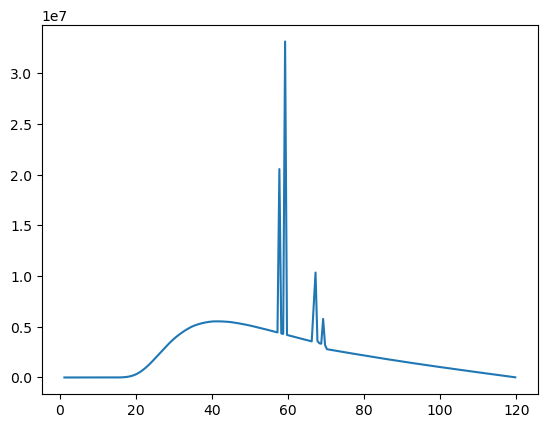

In [10]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

k_70 = 70
k_65 = 65
k_70_index = np.argmin(np.abs(xx - k_70))
k_65_index = np.argmin(np.abs(xx2 - k_65))

# Calculate the percent of the fluence between the k-edges 
fluence_to_65_120 = np.sum(yy[k_20_index:k_65_index]) / np.sum(yy)
fluence_to_70_140 = np.sum(yy2[k_20_index:k_70_index]) / np.sum(yy2)
fluence_65_to_120 = np.sum(yy[k_65_index:]) / np.sum(yy)
fluence_70_to_140 = np.sum(yy2[k_70_index:]) / np.sum(yy2)


# Find the mean energy in each num_regions

# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_65_120 = np.sum(xx[k_20_index:k_65_index]*(yy[k_20_index:k_65_index]/np.sum(yy[k_20_index:k_65_index])))
mean_energy_to_70_140 = np.sum(xx2[k_20_index:k_70_index]*(yy2[k_20_index:k_70_index]/np.sum(yy2[k_20_index:k_70_index])))
mean_energy_65_120 = np.sum(xx[k_65_index:]*(yy[k_65_index:]/np.sum(yy[k_65_index:])))
mean_energy_70_140 = np.sum(xx2[k_70_index:]*(yy2[k_70_index:]/np.sum(yy2[k_70_index:])))
                                
plt.figure()
plt.plot(xx, yy, label='120 kVp')
# plt.plot(xx2, yy2, label='140 kVp')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
plt.axvline(k_65, linestyle=':', label=f'65 keV bin',color='cornflowerblue')
# plt.axvline(k_70, linestyle=':', label=f'70 keV bin',color='orange')

# mu_at_mean_energy_120 = mu_bi(mean_energy_120)
# mu_at_mean_energy_140 = mu_bi(mean_energy_140)

mu_at_mean_energy_to_65_120 = mu_bi(mean_energy_to_65_120)
# mu_at_mean_energy_to_70_140 = mu_bi(mean_energy_to_70_140)
mu_at_mean_energy_65_120 = mu_bi(mean_energy_65_120)
# mu_at_mean_energy_70_140 = mu_bi(mean_energy_70_140)

# show the percent of the fluence between the k-edges in each num_regions
plt.text((k_65+20)/2, 0.4*max(yy), f'$\mu$\n{mu_at_mean_energy_to_65_120:.2f}\ncm$^{-1}$',color='r',ha='center',fontsize=14)
# plt.text((k_70+20)/2, 0.6*max(yy), f'{mu_at_mean_energy_to_70_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
plt.text((k_65+max(xx))/2, 0.4*max(yy), f'$\mu$\n{mu_at_mean_energy_65_120:.2f}\ncm$^{-1}$',color='b',ha='center',fontsize=14)
# plt.text((k_70+max(xx))/2, 0.6*max(yy), f'{mu_at_mean_energy_70_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
# show the mean energy in each of the regions 
# plt.text((k_65+20)/2, 0.6*max(yy), f'$E$\n{mean_energy_to_65_120:.2f}\nkeV',color='r',ha='center',fontsize=14)
# # plt.text((k_70+20)/2, 0.6*max(yy), f'{mean_energy_to_70_140:.2f}\nkeV',color='orange',ha='center')
# plt.text((k_65+max(xx))/2, 0.6*max(yy), f'$E$\n{mean_energy_65_120:.2f}\nkeV',color='b',ha='center',fontsize=14)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.title('$\mu$ Bismuth at the mean energy in each region')
# plt.legend()

plt.axvspan(k_20, k_65, color='r', alpha=0.1, label='low energy image')
plt.axvspan(k_65, max(xx), color='b', alpha=0.1, label='high energy image')

# Save the plot
plt.savefig('spectra_bi_gd_mu_bi_real_mu.png', dpi=300)

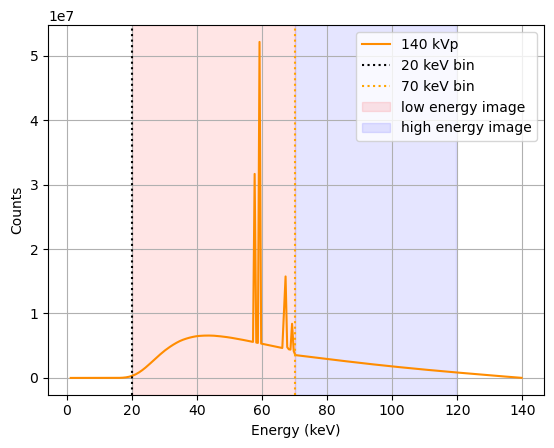

In [20]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

k_20 =20
k_70 = 70
k_65 = 65
k_70_index = np.argmin(np.abs(xx - k_70))
k_65_index = np.argmin(np.abs(xx2 - k_65))

# Calculate the percent of the fluence between the k-edges 
fluence_to_65_120 = np.sum(yy[k_20_index:k_65_index]) / np.sum(yy)
fluence_to_70_140 = np.sum(yy2[k_20_index:k_70_index]) / np.sum(yy2)
fluence_65_to_120 = np.sum(yy[k_65_index:]) / np.sum(yy)
fluence_70_to_140 = np.sum(yy2[k_70_index:]) / np.sum(yy2)


# Find the mean energy in each num_regions

# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_65_120 = np.sum(xx[k_20_index:k_65_index]*(yy[k_20_index:k_65_index]/np.sum(yy[k_20_index:k_65_index])))
mean_energy_to_70_140 = np.sum(xx2[k_20_index:k_70_index]*(yy2[k_20_index:k_70_index]/np.sum(yy2[k_20_index:k_70_index])))
mean_energy_65_120 = np.sum(xx[k_65_index:]*(yy[k_65_index:]/np.sum(yy[k_65_index:])))
mean_energy_70_140 = np.sum(xx2[k_70_index:]*(yy2[k_70_index:]/np.sum(yy2[k_70_index:])))
                                
plt.figure()
# plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='140 kVp', c = 'darkorange')

# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
# plt.axvline(k_65, linestyle=':', label=f'65 keV bin',color='cornflowerblue')
plt.axvline(k_70, linestyle=':', label=f'70 keV bin',color='orange')

# plot to regions between the k_20 and the k_65 and k_65 and the end of the spectrum
# plt.axvspan(k_20, k_65, color='r', alpha=0.1, label='low energy image')
# plt.axvspan(k_65, max(xx), color='b', alpha=0.1, label='high energy image')
# plot to regions between the k_20 and the k_70 and k_70 and the end of the spectrum
plt.axvspan(k_20, k_70, color='r', alpha=0.1, label='low energy image')
plt.axvspan(k_70, max(xx), color='b', alpha=0.1, label='high energy image')

# mu_at_mean_energy_120 = mu_bi(mean_energy_120)
# mu_at_mean_energy_140 = mu_bi(mean_energy_140)

mu_at_mean_energy_to_65_120 = mu_bi(mean_energy_to_65_120)
mu_at_mean_energy_to_70_140 = mu_bi(mean_energy_to_70_140)
mu_at_mean_energy_65_120 = mu_bi(mean_energy_65_120)
mu_at_mean_energy_70_140 = mu_bi(mean_energy_70_140)

# show the percent of the fluence between the k-edges in each num_regions
# plt.text((k_65+20)/2, 0.4*max(yy), f'{mu_at_mean_energy_to_65_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')
# plt.text((k_70+20)/2, 0.6*max(yy), f'{mu_at_mean_energy_to_70_140:.2f}\ncm$^{-1}$',color='orange',ha='center')
# plt.text((k_65+max(xx))/2, 0.4*max(yy), f'{mu_at_mean_energy_65_120:.2f}\ncm$^{-1}$',color='cornflowerblue',ha='center')
# plt.text((k_70+max(xx))/2, 0.6*max(yy), f'{mu_at_mean_energy_70_140:.2f}\ncm$^{-1}$',color='orange',ha='center')


plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()
# plt.title('$\mu$ Bismuth at the mean energy in each region')
# plt.legend()

# Save the plot
plt.savefig('spectra_140_bins.png', dpi=300)

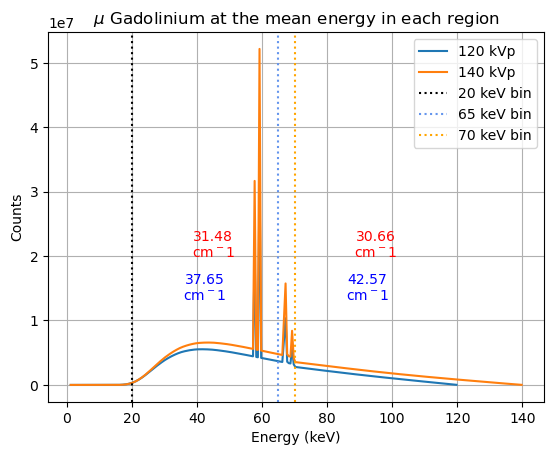

In [81]:
# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

k_70 = 70
k_65 = 65
k_70_index = np.argmin(np.abs(xx - k_70))
k_65_index = np.argmin(np.abs(xx2 - k_65))

# Calculate the percent of the fluence between the k-edges 
fluence_to_65_120 = np.sum(yy[k_20_index:k_65_index]) / np.sum(yy)
fluence_to_70_140 = np.sum(yy2[k_20_index:k_70_index]) / np.sum(yy2)
fluence_65_to_120 = np.sum(yy[k_65_index:]) / np.sum(yy)
fluence_70_to_140 = np.sum(yy2[k_70_index:]) / np.sum(yy2)


# Find the mean energy in each num_regions

# Calculate the mean energy in each num_regions as a weighted average of the energy time the fluence in each bin
mean_energy_to_65_120 = np.sum(xx[k_20_index:k_65_index]*(yy[k_20_index:k_65_index]/np.sum(yy[k_20_index:k_65_index])))
mean_energy_to_70_140 = np.sum(xx2[k_20_index:k_70_index]*(yy2[k_20_index:k_70_index]/np.sum(yy2[k_20_index:k_70_index])))
mean_energy_65_120 = np.sum(xx[k_65_index:]*(yy[k_65_index:]/np.sum(yy[k_65_index:])))
mean_energy_70_140 = np.sum(xx2[k_70_index:]*(yy2[k_70_index:]/np.sum(yy2[k_70_index:])))
                                
plt.figure()
plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='140 kVp')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
plt.axvline(k_65, linestyle=':', label=f'65 keV bin',color='cornflowerblue')
plt.axvline(k_70, linestyle=':', label=f'70 keV bin',color='orange')

# mu_at_mean_energy_120 = mu_bi(mean_energy_120)
# mu_at_mean_energy_140 = mu_bi(mean_energy_140)

mu_at_mean_energy_to_65_120 = mu_gd(mean_energy_to_65_120)
mu_at_mean_energy_to_70_140 = mu_gd(mean_energy_to_70_140)
mu_at_mean_energy_65_120 = mu_gd(mean_energy_65_120)
mu_at_mean_energy_70_140 = mu_gd(mean_energy_70_140)

# show the percent of the fluence between the k-edges in each num_regions
plt.text((k_65+20)/2, 0.4*max(yy), f'{mu_at_mean_energy_to_65_120:.2f}\ncm$^{-1}$',color='b',ha='center')
plt.text((k_70+20)/2, 0.6*max(yy), f'{mu_at_mean_energy_to_70_140:.2f}\ncm$^{-1}$',color='red',ha='center')
plt.text((k_65+max(xx))/2, 0.4*max(yy), f'{mu_at_mean_energy_65_120:.2f}\ncm$^{-1}$',color='b',ha='center')
plt.text((k_70+max(xx))/2, 0.6*max(yy), f'{mu_at_mean_energy_70_140:.2f}\ncm$^{-1}$',color='red',ha='center')


plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.title('$\mu$ Gadolinium at the mean energy in each region')
plt.legend()

# Save the plot
plt.savefig('spectra_bi_gd_mu_gd_real.png', dpi=300)

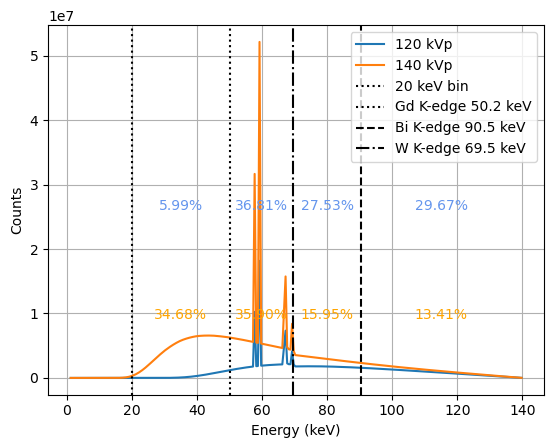

In [84]:
s = sp.Spek(140,14)
s.filter('Al',4)
s.filter('Ti',0.89)
s.filter('Cu',0.5)

xx, yy = s.get_spectrum()

# Find the closes xx and xx2 values to the k-edge energies
k_bi_index = np.argmin(np.abs(xx - k_bi))
k_gd_index = np.argmin(np.abs(xx2 - k_gd))
k_W_index = np.argmin(np.abs(xx - 69.5))
k_20_index = np.argmin(np.abs(xx - 20))

k_20 = 20
k_W = 69.5
# Calculate the percent of the fluence between the k-edges 
fluence_to_gd_120 = np.sum(yy[k_20_index:k_gd_index]) / np.sum(yy)
fluence_to_gd_140 = np.sum(yy2[k_20_index:k_gd_index]) / np.sum(yy2)
fluence_gd_to_W_120 = np.sum(yy[k_gd_index:k_W_index]) / np.sum(yy)
fluence_gd_to_W_140 = np.sum(yy2[k_gd_index:k_W_index]) / np.sum(yy2)
fluence_W_to_bi_120 = np.sum(yy[k_W_index:k_bi_index]) / np.sum(yy)
fluence_W_to_bi_140 = np.sum(yy2[k_W_index:k_bi_index]) / np.sum(yy2)
fluence_bi_120 = np.sum(yy[k_bi_index:]) / np.sum(yy)
fluence_bi_140 = np.sum(yy2[k_bi_index:]) / np.sum(yy2)

plt.figure()
plt.plot(xx, yy, label='120 kVp')
plt.plot(xx2, yy2, label='140 kVp')
# plot the k_bismuth and k_gadolinium lines
# plot the k_tungsten line as well
# Show the percent of the fluence between the k-edges
plt.axvline(k_20, color='k', linestyle=':', label=f'20 keV bin')
plt.axvline(k_gd, color='k', linestyle=':', label=f'Gd K-edge {k_gd} keV')
plt.axvline(k_bi, color='k', linestyle='--', label=f'Bi K-edge {k_bi} keV')
plt.axvline(69.5, color='k', linestyle='-.', label=f'W K-edge 69.5 keV')

# show the percent of the fluence between the k-edges in each num_regions
plt.text((k_gd+20)/2, 0.5*max(yy2), f'{fluence_to_gd_120:.2%}',color='cornflowerblue',ha='center')
plt.text((k_gd+k_W)/2, 0.5*max(yy2), f'{fluence_gd_to_W_120:.2%}',color='cornflowerblue',ha='center')
plt.text((k_W+k_bi)/2, 0.5*max(yy2), f'{fluence_W_to_bi_120:.2%}',color='cornflowerblue',ha='center')
plt.text((k_bi+max(xx))/2, 0.5*max(yy2), f'{fluence_bi_120:.2%}',color='cornflowerblue',ha='center')

plt.text((k_gd+20)/2, 0.5*max(yy), f'{fluence_to_gd_140:.2%}',color='orange',ha='center')
plt.text((k_gd+k_W)/2, 0.5*max(yy), f'{fluence_gd_to_W_140:.2%}',color='orange',ha='center')
plt.text((k_W+k_bi)/2, 0.5*max(yy), f'{fluence_W_to_bi_140:.2%}',color='orange',ha='center')
plt.text((k_bi+max(xx))/2, 0.5*max(yy), f'{fluence_bi_140:.2%}',color='orange',ha='center')

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.grid()
plt.legend()

# Save the plot
plt.savefig('spectra_bi_gd_hard_spec.png', dpi=300)

Text(0, 0.5, 'Fluence')

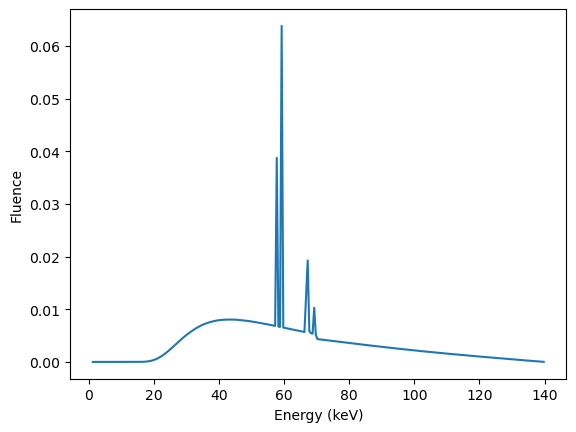

In [6]:
s = sp.Spek(140,14)
s.filter('Al',4)

plt.figure()
plt.plot(s.get_spectrum()[0],s.get_spectrum()[1]/np.sum(s.get_spectrum()[1]),label='140 kVp')
plt.xlabel('Energy (keV)')
plt.ylabel('Fluence')


In [5]:
import spekpy as sp
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import fastcat as fc

phantom = fc.Catphan_404_Devon()

[2024-02-06 16:00:47,051] {colorbar.py:859} DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7f5deef77dd0>


(-0.5, 511.5, 511.5, -0.5)

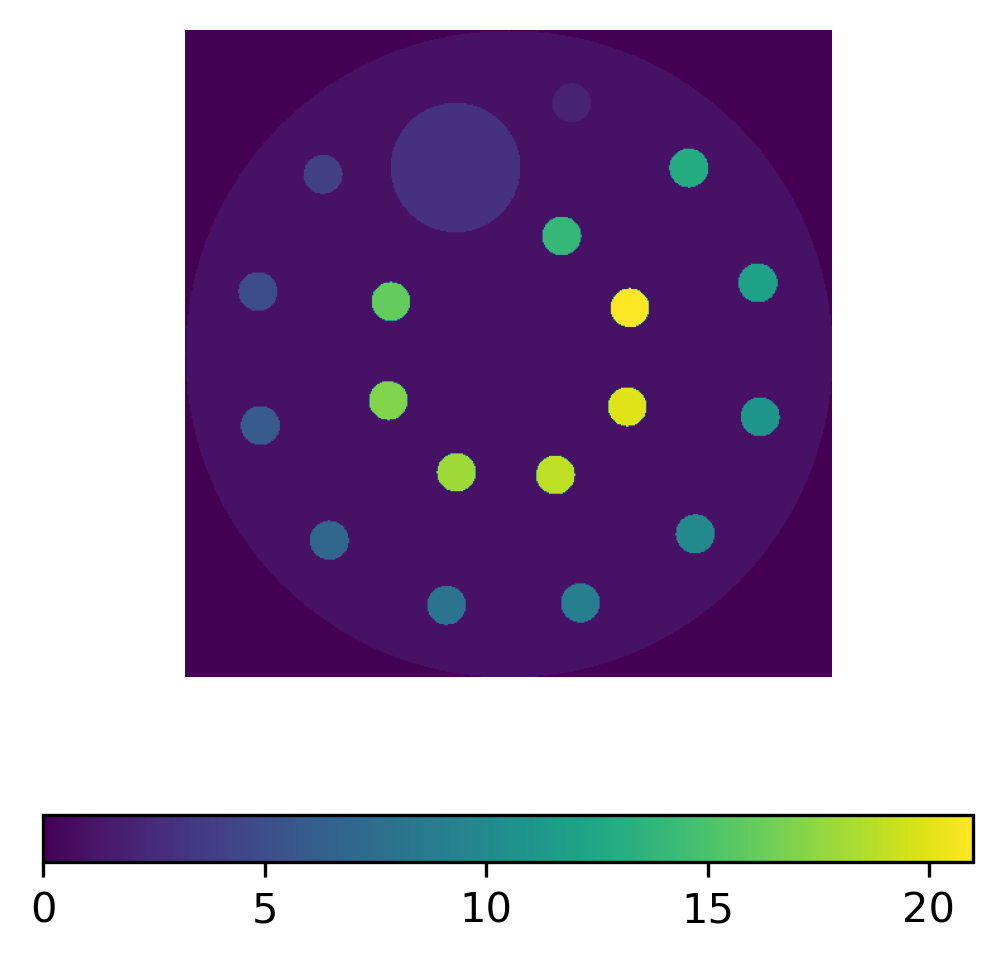

In [12]:
plt.figure(figsize=[    4,  4], dpi=300)
plt.imshow(phantom.phantom[5])
plt.colorbar(orientation='horizontal')
plt.axis('off')